# Planning a telescope observation

The objective is to build a weather forecast to plan an expensive observational campaign, by knowing that the weather tomorrow depends on the one today as:
* p(clear tomorrow|cloudy today) = 0.5 and p(cloudy tomorrow|cloudy today) = 0.5 ;
* p(clear tomorrow|clear today) = 0.9 and p(cloudy tomorrow|clear today) = 0.1 .

The prediction algorithm will be built through a Markov Chain as follows. Starting from the current day the prediction on tomorrow will be ruled by the drawn of a number from a uniform distribution between 0 and 1 U[0,1]. This number is then compared in magnitude to the corresponding probability, depending on the weather today: to be explicit, if today is a clear day and the number I extracted is smaller than 0.1, then tomorrow will be identified as cloudy (indeed I have 10% of probability to draw a number smaller than 0.1 from U[0,1]).

After enough days, if the chain is stationary and well defined, the equilibrium probabilities should be reached: p(clear) = 0.83 and p(cloudy) = 0.17

### Tasks

* Start off on a cloudy day;
* Implement your weather forecast based on the above probabilities
* Run your simulator for N days (with $N>10^4$);
* Prepare a plot with the number of days on the x axis and the cumulative fraction of, say, sunny days over the number of days so far on the y axis. This is called a trace-plot, showing how our estimate of p(clear) evolves as the chain samples.
* Prepare a histogram of the above plot. This reveals the distribution of p(clear).
* Use a summary statistics to determine the most likely value and an error on our estimate.

In [2]:
import numpy as np

In [63]:
# 0 cloudy
# 1 clear

N =10**4

def sunnycloudy_MC(N, init=0):
    chain = [init]
    for i in range(N):
        next_prob =  np.random.uniform(0,1,1)
        next_day = 0
        if init == 0: #today is cloudy
            if next_prob <0.5:
                chain.append(0)
                next_day = 0
            else:
                chain.append(1)
                next_day = 1
                
        else:        #today is clear
            if next_prob<0.1:
                chain.append(0)
                next_day = 0
            else:
                chain.append(1)
                next_day = 1
        init = next_day #next step
    return chain
        
        
        

In [64]:
days = sunnycloudy_MC(N)

Text(0.5, 1.0, 'Traceplot')

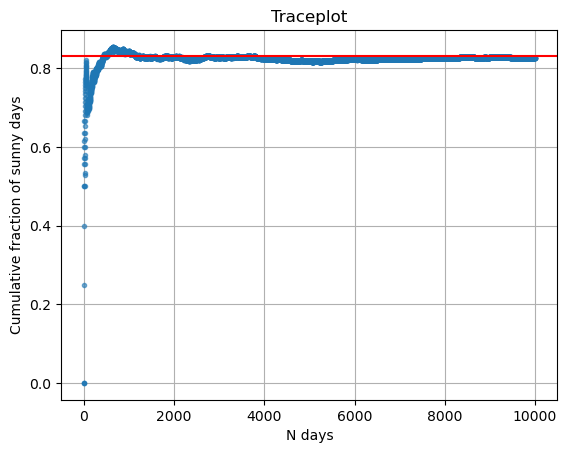

In [65]:
import matplotlib.pyplot as plt

x = np.arange(N)
cum = [np.sum(days[:i])/(i+1) for i in range(N)]
plt.plot(x, cum, '.', alpha=0.6)
plt.axhline(0.83, color='red')
plt.xlabel('N days')
plt.ylabel('Cumulative fraction of sunny days')
plt.grid()
plt.title('Traceplot')

In [23]:
def scott_rule_histo(data):
    bin_width = 3.5*np.std(data)/len(data)**(1/3)
    bins = np.append(np.arange(start=data.min(), stop=data.max(), step=bin_width) , data.max())  # Create edges
   # print(f"Scott's bin width: {bin_width}")
    return bins


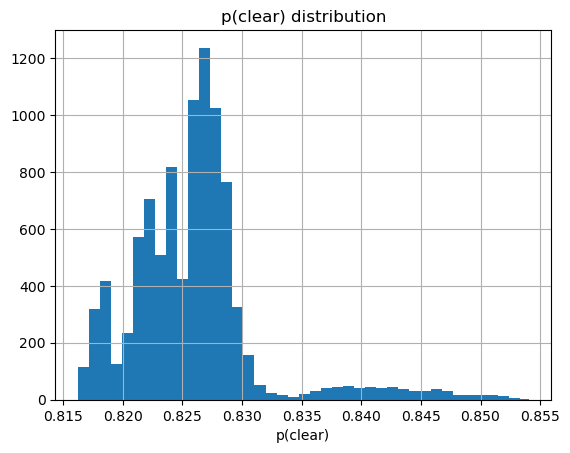

In [67]:
#reject the burn in phase of the traceplot

plt.hist(cum[500:], bins= scott_rule_histo(np.array(cum[500:])))#, density='True')
plt.grid()
plt.xlabel('p(clear)')
plt.title('p(clear) distribution')
plt.show()

In [28]:
np.mean(cum[500:])

0.8324288167345162

In [29]:
np.std(cum[500:])/len(cum[500:])

1.0343666432568475e-06

Text(0.5, 1.0, 'Traceplot')

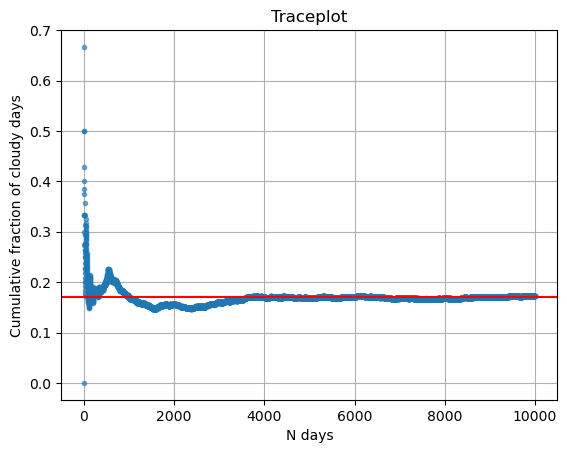

In [41]:
x = np.arange(N)
days_aus = np.array(days)
index_0 = np.where(np.array(days)==0)[0]
index_1 = np.where(np.array(days)==1)[0]
days_aus[index_0]= 1
days_aus[index_1] = 0
cum = [np.sum(days_aus[:i])/(i+1) for i in range(N)]
plt.plot(x, cum, '.', alpha=0.6)
plt.axhline(0.17, color='red')
plt.xlabel('N days')
plt.ylabel('Cumulative fraction of cloudy days')
plt.grid()
plt.title('Traceplot')

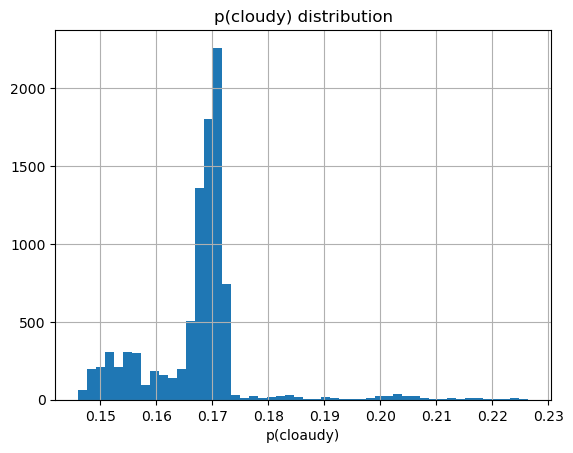

In [44]:
#reject the burn in phase of the traceplot

plt.hist(cum[500:], bins= scott_rule_histo(np.array(cum[500:])))#, density='True')
plt.grid()
plt.xlabel('p(cloaudy)')
plt.title('p(cloudy) distribution')
plt.show()

In [45]:
np.mean(cum[500:])

0.16725594299116228

In [46]:
np.std(cum[500:])/len(cum[500:])

1.0240688132331542e-06

# Stock market

In [59]:
# 1 recession
# 2 bear
# 3 bull

N =10**6

def stock_MC(N, init=1):
    chain = [init]
    for i in range(N):
        next_prob =  np.random.uniform(0,1,1)
        next_day = 1
        if init == 1: 
            if next_prob <0.5:
                chain.append(1)
                next_day = 1
            elif next_prob>0.75:
                chain.append(2)
                next_day = 2
            else:
                chain.append(3)
                next_day = 3
                
        elif init==2:        #today is clear
            if next_prob<0.8:
                chain.append(2)
                next_day = 2
            elif next_prob>0.95:
                chain.append(1)
                next_day = 1
            else:
                chain.append(3)
                next_day = 3
        else:
            if next_prob<0.9:
                chain.append(3)
                next_day = 3
            elif next_prob>0.925:
                chain.append(2)
                next_day = 2
            else:
                chain.append(1)
                next_day=1
                
        init = next_day #next step
    return chain
        
        
        

In [60]:
market = stock_MC(N)

In [61]:
x = np.arange(N)
market_aus = np.array(market)
mask_2 = np.where(market_aus ==2)
mask_3 = np.where(market_aus ==3)
market_aus[mask_2]=0
market_aus[mask_3]=0
cum = [np.sum(market_aus[:i])/(i+1) for i in range(N)]
plt.plot(x, cum, '.', alpha=0.6)
plt.xlabel('N days')
plt.ylabel('Cumulative fraction of recessional days')
plt.grid()
plt.title('Traceplot')

KeyboardInterrupt: 

In [ ]:
#reject the burn in phase of the traceplot

plt.hist(cum[500:], bins= scott_rule_histo(np.array(cum[500:])))#, density='True')
plt.grid()
plt.xlabel('p(recession)')
plt.title('p(recession) distribution')
plt.show()

Text(0.5, 1.0, 'Traceplot')

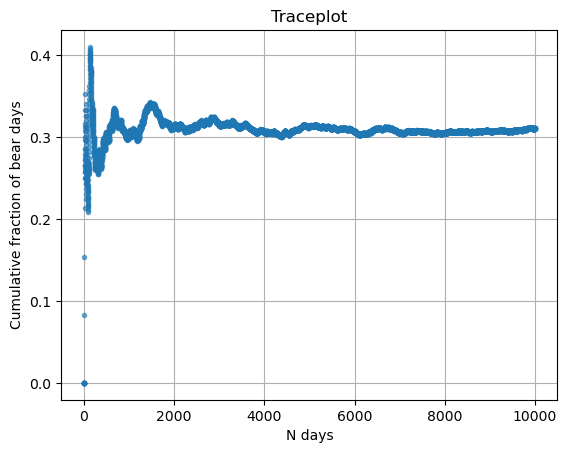

In [55]:
x = np.arange(N)
market_aus = np.array(market)
mask_2 = np.where(market_aus ==1)
mask_3 = np.where(market_aus ==3)
market_aus[mask_2]=0
market_aus[mask_3]=0
cum = [0.5*np.sum(market_aus[:i])/(i+1) for i in range(N)]
plt.plot(x, cum, '.', alpha=0.6)
plt.xlabel('N days')
plt.ylabel('Cumulative fraction of bear days')
plt.grid()
plt.title('Traceplot')

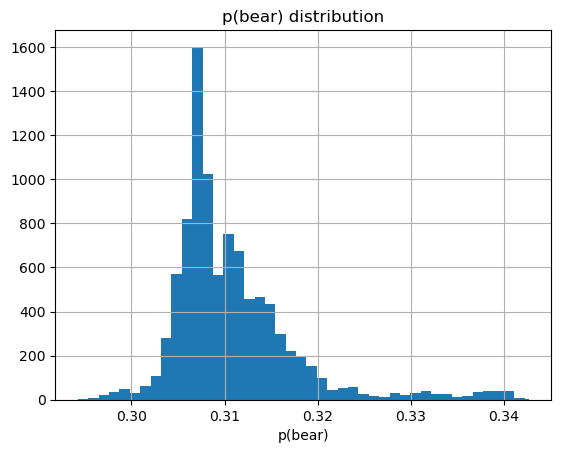

In [56]:
#reject the burn in phase of the traceplot

plt.hist(cum[500:], bins= scott_rule_histo(np.array(cum[500:])))#, density='True')
plt.grid()
plt.xlabel('p(bear)')
plt.title('p(bear) distribution')
plt.show()

Text(0.5, 1.0, 'Traceplot')

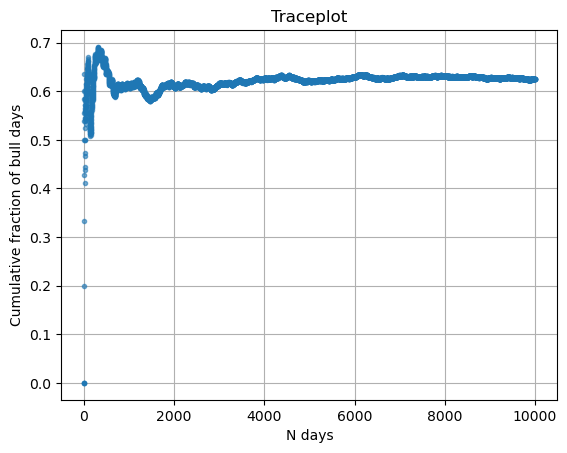

In [53]:
x = np.arange(N)
market_aus = np.array(market)
mask_2 = np.where(market_aus ==2)
mask_3 = np.where(market_aus ==1)
market_aus[mask_2]=0
market_aus[mask_3]=0
cum = [np.sum(market_aus[:i])/(i+1) *(1/3) for i in range(N)]
plt.plot(x, cum, '.', alpha=0.6)
plt.xlabel('N days')
plt.ylabel('Cumulative fraction of bull days')
plt.grid()
plt.title('Traceplot')

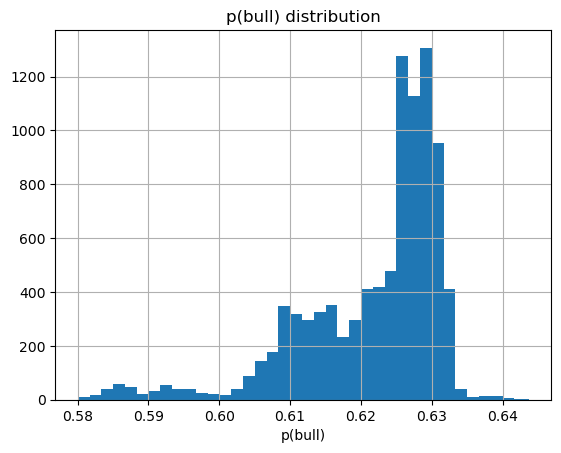

In [54]:
#reject the burn in phase of the traceplot

plt.hist(cum[500:], bins= scott_rule_histo(np.array(cum[500:])))#, density='True')
plt.grid()
plt.xlabel('p(bull)')
plt.title('p(bull) distribution')
plt.show()